# Notebook 09 — Validate and Tune Two Models

## Purpose
This notebook performs the **final independent evaluation** of the trained  
classifiers using the normalized **25-dimensional Digital Image Processing  
(DIP) feature vectors** from the held-out test dataset.

The two classifiers trained in Notebook 08 — **RBF SVM** and **MLP** — are  
applied to the test set exactly once to measure generalization performance.  
This notebook provides the final unbiased comparison of the retained models.

---

## Inputs
This notebook uses the normalized dataset generated by:

- `06_Normalize_and_Prepare_Classifier_Input.ipynb`

Expected input files:

- `test_feature_vectors_normalized.csv`

Saved model artifacts generated by:

- `08_Train_Two_Classifiers.ipynb`

Expected model and metadata files:

- `model_rbf_svm.pkl`
- `model_mlp.pkl`
- `trained_model_configs.json`
- `cross_validation_results.csv`

---

## Local Execution Assumptions
This notebook is designed to run within the **local GitHub project structure**  
or a compatible environment (e.g., Google Colab).

It assumes:

- the project repository is available locally or cloned at runtime  
- `src/project_config.py` is accessible  
- prior pipeline notebooks have generated the required normalized datasets  
- Notebook 08 has generated trained model files and configuration outputs  
- required Python packages (NumPy, pandas, scikit-learn, matplotlib, seaborn) are installed  

---

## Important Note
All features have already been normalized using a scaler fit only on the  
training dataset in Notebook 06. No additional normalization is performed here.

This notebook uses the **held-out test set only**. No classifier selection,  
hyperparameter tuning, or retraining occurs in this notebook.

---

## Process Overview
This notebook evaluates the retained classifiers on the independent test set  
using a consistent final-evaluation framework. The workflow includes:

1. loading and validating the normalized test dataset  
2. separating metadata from feature columns  
3. loading trained classifier artifacts  
4. generating predictions and probability scores  
5. computing final evaluation metrics  
6. generating confusion matrices  
7. generating ROC curves  
8. summarizing final results in tabular form  
9. saving evaluation outputs for reporting and documentation  

---

## Outputs
This notebook produces:

- final test-set performance metrics for both classifiers  
- confusion matrices (raw and normalized)  
- ROC curves for both classifiers  
- summary tables comparing model performance  
- saved evaluation outputs:

  - `final_test_results.csv`  
  - `final_test_results.json`  
  - `confusion_matrix_mlp.csv`  
  - `confusion_matrix_rbf_svm.csv`  
  - `roc_points_mlp.csv`  
  - `roc_points_rbf_svm.csv`  

All outputs are saved under:
    metadata/models


---

## Key Design Choice
This notebook performs **independent final evaluation**, not model selection or training.

Both classifiers retained from Notebook 08 are evaluated on the same held-out  
test set to ensure a fair and unbiased comparison.

This design:

- preserves strict separation between training and testing  
- prevents data leakage  
- provides a reliable estimate of real-world generalization performance  
- enables direct comparison between model families  

---

## Models Evaluated
The classifiers evaluated in this notebook are:

- RBF Support Vector Machine (RBF SVM)  
- Multi-Layer Perceptron (MLP)  

Both models were trained in Notebook 08 and are loaded here as saved `.pkl` artifacts.

---

## Scope Limitation
This notebook does **not** perform:

- classifier selection  
- hyperparameter tuning  
- retraining on the test set  

These steps were completed in earlier notebooks.

---

## Cell-by-Cell Structure

### Cell 1
Import required libraries and configure environment settings.

### Cell 2
Load the normalized test dataset and trained model artifacts.

### Cell 3
Validate dataset integrity and prepare feature matrix (`X_test`) and labels (`y_test`).

### Cell 4
Generate predictions and probability scores for both classifiers.

### Cell 5
Compute final evaluation metrics (accuracy, precision, recall, F1-score, ROC-AUC).

### Cell 6
Generate and display confusion matrices (side-by-side comparison).

### Cell 7
Generate and display ROC curves.

### Cell 8
Summarize final results in tabular form.

### Cell 9
Save final evaluation outputs for reporting and documentation.


In [10]:
# ============================================
# Startup (Environment + Verification)
# ============================================

import os
import sys
from pathlib import Path

# -------------------------------------------------
# Clone repo into Colab runtime (if not already present)
# -------------------------------------------------
REPO_URL = "https://github.com/pgailinas/dip-ai-image-detection.git"
REPO_DIR = Path("/content/dip-ai-image-detection")

if not REPO_DIR.exists():
    print("Cloning repository...")
    os.system(f"git clone {REPO_URL} {REPO_DIR}")

# -------------------------------------------------
# Make src/ importable
# -------------------------------------------------
SRC_DIR = REPO_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# -------------------------------------------------
# Import shared project configuration
# -------------------------------------------------
from project_config import (
    TEST_NORMALIZED_FILENAME,
    NUM_FEATURES,
    METADATA_COLUMNS,
    AI_LABEL,
    REAL_LABEL,
    VALID_LABELS,
    TEST_SUBSET,
)

print("Project configuration loaded successfully.")

# -------------------------------------------------
# Notebook 09 path overrides
# -------------------------------------------------
METADATA_ROOT = REPO_DIR / "metadata"
INPUT_CSV_DIR = METADATA_ROOT / "vectors"
MODELS_DIR = METADATA_ROOT / "models"

# -------------------------------------------------
# Define required file paths
# -------------------------------------------------
TEST_FEATURES_PATH = INPUT_CSV_DIR / TEST_NORMALIZED_FILENAME

MLP_MODEL_PATH = MODELS_DIR / "model_mlp.pkl"
RBF_MODEL_PATH = MODELS_DIR / "model_rbf_svm.pkl"

TRAINED_CONFIGS_JSON = MODELS_DIR / "trained_model_configs.json"
CV_RESULTS_CSV = MODELS_DIR / "cross_validation_results.csv"

# -------------------------------------------------
# Verify required input files
# -------------------------------------------------
print("\nVerifying required input files...\n")

required_files = [
    TEST_FEATURES_PATH,
    MLP_MODEL_PATH,
    RBF_MODEL_PATH,
    TRAINED_CONFIGS_JSON,
    CV_RESULTS_CSV,
]

missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n" + "\n".join(missing_files)
    )

print("All required input files are present.")
print(f"Test features:         {TEST_FEATURES_PATH}")
print(f"MLP model:             {MLP_MODEL_PATH}")
print(f"RBF SVM model:         {RBF_MODEL_PATH}")
print(f"Model configs JSON:    {TRAINED_CONFIGS_JSON}")
print(f"CV results CSV:        {CV_RESULTS_CSV}")
print(f"Models directory:      {MODELS_DIR}")



Project configuration loaded successfully.

Verifying required input files...

All required input files are present.
Test features:         /content/dip-ai-image-detection/metadata/vectors/test_feature_vectors_normalized.csv
MLP model:             /content/dip-ai-image-detection/metadata/models/model_mlp.pkl
RBF SVM model:         /content/dip-ai-image-detection/metadata/models/model_rbf_svm.pkl
Model configs JSON:    /content/dip-ai-image-detection/metadata/models/trained_model_configs.json
CV results CSV:        /content/dip-ai-image-detection/metadata/models/cross_validation_results.csv
Models directory:      /content/dip-ai-image-detection/metadata/models


In [11]:
# ============================================================
# Cell 1: Import Required Libraries
# ============================================================

# ------------------------------------------------------------
# Standard libraries
# ------------------------------------------------------------
import os
import json
import pickle

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Sklearn metrics
# ------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
)

# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# Column definitions
# ------------------------------------------------------------
METADATA_COLS = METADATA_COLUMNS.copy()
FEATURE_COLS = None

# ------------------------------------------------------------
# Class label definitions
# ------------------------------------------------------------
CLASS_LABELS = VALID_LABELS
POSITIVE_CLASS = AI_LABEL

# ------------------------------------------------------------
# Visualization settings
# ------------------------------------------------------------
sns.set(style="whitegrid")

print("Libraries imported successfully.")



Libraries imported successfully.


In [12]:
# ============================================================
# Cell 2: Load Test Data and Saved Model Artifacts
# ============================================================

# ------------------------------------------------------------
# Load normalized test dataset
# ------------------------------------------------------------
df_test = pd.read_csv(TEST_FEATURES_PATH)

print("Normalized test dataset loaded successfully.")
print(f"Test data shape: {df_test.shape}")

# ------------------------------------------------------------
# Identify metadata and feature columns
# ------------------------------------------------------------
FEATURE_COLS = [col for col in df_test.columns if col not in METADATA_COLS]

print(f"\nMetadata columns ({len(METADATA_COLS)}): {METADATA_COLS}")
print(f"Feature columns ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

# ------------------------------------------------------------
# Verify expected feature count
# ------------------------------------------------------------
if len(FEATURE_COLS) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} feature columns, "
        f"but found {len(FEATURE_COLS)}."
    )

print(f"\nFeature count check passed: {len(FEATURE_COLS)} features found.")

# ------------------------------------------------------------
# Load final trained models
# ------------------------------------------------------------
with open(MLP_MODEL_PATH, "rb") as f:
    mlp_model = pickle.load(f)

with open(RBF_MODEL_PATH, "rb") as f:
    rbf_model = pickle.load(f)

print(f"\nFinal MLP model loaded successfully: {MLP_MODEL_PATH.name}")
print(f"Final RBF SVM model loaded successfully: {RBF_MODEL_PATH.name}")

# ------------------------------------------------------------
# Load trained model configuration summary
# ------------------------------------------------------------
with open(TRAINED_CONFIGS_JSON, "r") as f:
    trained_model_configs = json.load(f)

print("Trained model configuration summary loaded successfully.")

# ------------------------------------------------------------
# Load cross-validation results
# ------------------------------------------------------------
df_cv_results = pd.read_csv(CV_RESULTS_CSV)

print(f"Cross-validation results loaded successfully: {CV_RESULTS_CSV.name}")



Normalized test dataset loaded successfully.
Test data shape: (3600, 29)

Metadata columns (4): ['filename', 'class_label', 'source_dataset', 'subset']
Feature columns (25):
['Mean Gradient', 'Std Gradient', 'Max Gradient', 'Gradient Entropy', 'Edge Density', 'Orientation Mean', 'Orientation Std', 'Orientation Entropy', 'Global Entropy', 'Local Entropy Mean', 'Local Entropy Std', 'Intensity Mean', 'Intensity Std', 'Laplacian Variance', 'Patch Variance Mean', 'Patch Variance Std', 'Noise Residual Energy', 'Low Frequency Energy Ratio', 'High Frequency Energy Ratio', 'Radial Mean', 'Radial Std', 'Radial Entropy', 'Spectral Centroid', 'Spectral Bandwidth', 'Log Spectrum Std']

Feature count check passed: 25 features found.

Final MLP model loaded successfully: model_mlp.pkl
Final RBF SVM model loaded successfully: model_rbf_svm.pkl
Trained model configuration summary loaded successfully.
Cross-validation results loaded successfully: cross_validation_results.csv


In [13]:
# ============================================================
# Cell 3: Run Sanity Checks and Separate Features and Labels
# ============================================================

# ------------------------------------------------------------
# Verify required columns are present
# ------------------------------------------------------------
missing_metadata_cols = [col for col in METADATA_COLS if col not in df_test.columns]

if missing_metadata_cols:
    raise ValueError(
        f"Missing required metadata columns: {missing_metadata_cols}"
    )

if len(FEATURE_COLS) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} feature columns, but found {len(FEATURE_COLS)}."
    )

print("Required column check passed.")

# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------
total_missing = df_test.isnull().sum().sum()

if total_missing > 0:
    raise ValueError(f"Test dataset contains {total_missing} missing value(s).")

print("Missing value check passed.")

# ------------------------------------------------------------
# Verify class labels
# ------------------------------------------------------------
invalid_labels = sorted(set(df_test["class_label"]) - set(CLASS_LABELS))

if invalid_labels:
    raise ValueError(
        f"Unexpected class labels found: {invalid_labels}"
    )

print("Class label check passed.")

# ------------------------------------------------------------
# Verify subset column
# ------------------------------------------------------------
invalid_subsets = sorted(set(df_test["subset"]) - {TEST_SUBSET})

if invalid_subsets:
    raise ValueError(
        f"Unexpected subset values found in test data: {invalid_subsets}"
    )

print("Subset check passed.")

# ------------------------------------------------------------
# Separate features and labels
# ------------------------------------------------------------
X_test = df_test[FEATURE_COLS].copy()
y_test = df_test["class_label"].copy()

print("\nSeparated feature matrix and label vector successfully.")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# ------------------------------------------------------------
# Encode labels for ROC-AUC and related metrics
# ------------------------------------------------------------
y_test_binary = (y_test == POSITIVE_CLASS).astype(int)

print(f"\nPositive class for evaluation: '{POSITIVE_CLASS}'")
print("Binary label encoding created successfully.")

# ------------------------------------------------------------
# Display class distribution
# ------------------------------------------------------------
class_counts = y_test.value_counts().sort_index()

print("\nTest set class distribution:")
for label, count in class_counts.items():
    print(f"  {label}: {count}")

# ------------------------------------------------------------
# Display first few rows for verification
# ------------------------------------------------------------
print("\nFirst 5 rows of X_test:")
print(X_test.head())

print("\nFirst 10 labels in y_test:")
print(y_test.head(10).to_list())

print("\nFirst 10 labels in y_test_binary:")
print(y_test_binary.head(10).to_list())


Required column check passed.
Missing value check passed.
Class label check passed.
Subset check passed.

Separated feature matrix and label vector successfully.
X_test shape: (3600, 25)
y_test shape: (3600,)

Positive class for evaluation: 'ai'
Binary label encoding created successfully.

Test set class distribution:
  ai: 1800
  rl: 1800

First 5 rows of X_test:
   Mean Gradient  Std Gradient  Max Gradient  Gradient Entropy  Edge Density  Orientation Mean  Orientation Std  \
0       0.497872     -0.409551      0.681864          0.559988      0.054908         -0.305565         0.885148   
1       0.927560      0.358681      0.946748          0.880741      0.393183         -0.422829         0.274049   
2      -0.620579      0.043886      1.061698         -1.269570     -0.505036         -0.727340         1.345230   
3       0.403077     -0.557194     -1.870341          1.648585      1.121353          1.184433         1.068629   
4      -0.126248      0.518973      0.726811         -0.54

In [16]:
# ============================================================
# Cell 4: Generate Test-Set Predictions and Probabilities
# ============================================================

# ------------------------------------------------------------
# Generate predicted class labels (encoded)
# ------------------------------------------------------------
y_pred_mlp_encoded = mlp_model.predict(X_test)
y_pred_rbf_encoded = rbf_model.predict(X_test)

print("Predicted class labels generated successfully.")
print(f"Number of MLP predictions: {len(y_pred_mlp_encoded)}")
print(f"Number of RBF SVM predictions: {len(y_pred_rbf_encoded)}")

# ------------------------------------------------------------
# Generate class probabilities
# ------------------------------------------------------------
if hasattr(mlp_model, "predict_proba"):
    y_proba_mlp = mlp_model.predict_proba(X_test)
    print("MLP predicted class probabilities generated successfully.")
else:
    raise AttributeError(
        "The loaded MLP model does not support predict_proba()."
    )

if hasattr(rbf_model, "predict_proba"):
    y_proba_rbf = rbf_model.predict_proba(X_test)
    print("RBF SVM predicted class probabilities generated successfully.")
else:
    raise AttributeError(
        "The loaded RBF SVM model does not support predict_proba(). "
        "Ensure probability=True was enabled when training the RBF SVM."
    )

# ------------------------------------------------------------
# Determine encoded label mapping
# ------------------------------------------------------------
# LabelEncoder on ["ai", "rl"] gives:
#   ai -> 0
#   rl -> 1
positive_class_encoded = 0   # AI_LABEL
negative_class_encoded = 1   # REAL_LABEL

if not hasattr(mlp_model, "classes_"):
    raise AttributeError("The loaded MLP model does not expose classes_.")

if not hasattr(rbf_model, "classes_"):
    raise AttributeError("The loaded RBF SVM model does not expose classes_.")

mlp_class_order = list(mlp_model.classes_)
rbf_class_order = list(rbf_model.classes_)

if positive_class_encoded not in mlp_class_order:
    raise ValueError(
        f"Encoded positive class '{positive_class_encoded}' not found in "
        f"mlp_model.classes_: {mlp_class_order}"
    )

if positive_class_encoded not in rbf_class_order:
    raise ValueError(
        f"Encoded positive class '{positive_class_encoded}' not found in "
        f"rbf_model.classes_: {rbf_class_order}"
    )

mlp_positive_class_index = mlp_class_order.index(positive_class_encoded)
rbf_positive_class_index = rbf_class_order.index(positive_class_encoded)

y_score_mlp = y_proba_mlp[:, mlp_positive_class_index]
y_score_rbf = y_proba_rbf[:, rbf_positive_class_index]

# ------------------------------------------------------------
# Decode predicted labels back to original class strings
# ------------------------------------------------------------
# ai -> 0, rl -> 1
y_pred_mlp = np.where(y_pred_mlp_encoded == 0, AI_LABEL, REAL_LABEL)
y_pred_rbf = np.where(y_pred_rbf_encoded == 0, AI_LABEL, REAL_LABEL)

print(f"\nMLP class order: {mlp_class_order}")
print(f"MLP positive class index: {mlp_positive_class_index}")
print(f"MLP positive class for scoring: encoded {positive_class_encoded} -> '{AI_LABEL}'")

print(f"\nRBF SVM class order: {rbf_class_order}")
print(f"RBF SVM positive class index: {rbf_positive_class_index}")
print(f"RBF SVM positive class for scoring: encoded {positive_class_encoded} -> '{AI_LABEL}'")

# ------------------------------------------------------------
# Basic output checks
# ------------------------------------------------------------
if len(y_pred_mlp) != len(y_test):
    raise ValueError(
        f"MLP prediction length mismatch: len(y_pred_mlp)={len(y_pred_mlp)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_score_mlp) != len(y_test):
    raise ValueError(
        f"MLP score length mismatch: len(y_score_mlp)={len(y_score_mlp)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_pred_rbf) != len(y_test):
    raise ValueError(
        f"RBF SVM prediction length mismatch: len(y_pred_rbf)={len(y_pred_rbf)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_score_rbf) != len(y_test):
    raise ValueError(
        f"RBF SVM score length mismatch: len(y_score_rbf)={len(y_score_rbf)} "
        f"but len(y_test)={len(y_test)}"
    )

print("\nPrediction length checks passed.")

# ------------------------------------------------------------
# Preview outputs
# ------------------------------------------------------------
print("\nFirst 10 MLP predicted labels:")
print(y_pred_mlp[:10].tolist())

print("\nFirst 10 MLP positive-class probabilities:")
print(np.round(y_score_mlp[:10], 6).tolist())

print("\nFirst 10 RBF SVM predicted labels:")
print(y_pred_rbf[:10].tolist())

print("\nFirst 10 RBF SVM positive-class probabilities:")
print(np.round(y_score_rbf[:10], 6).tolist())



Predicted class labels generated successfully.
Number of MLP predictions: 3600
Number of RBF SVM predictions: 3600
MLP predicted class probabilities generated successfully.
RBF SVM predicted class probabilities generated successfully.

MLP class order: [np.int64(0), np.int64(1)]
MLP positive class index: 0
MLP positive class for scoring: encoded 0 -> 'ai'

RBF SVM class order: [np.int64(0), np.int64(1)]
RBF SVM positive class index: 0
RBF SVM positive class for scoring: encoded 0 -> 'ai'

Prediction length checks passed.

First 10 MLP predicted labels:
['rl', 'rl', 'rl', 'ai', 'rl', 'ai', 'rl', 'rl', 'ai', 'rl']

First 10 MLP positive-class probabilities:
[0.207809, 0.030117, 0.113216, 0.999831, 0.014801, 0.945815, 0.021301, 0.357323, 0.770692, 0.222066]

First 10 RBF SVM predicted labels:
['rl', 'rl', 'rl', 'ai', 'rl', 'ai', 'rl', 'rl', 'ai', 'rl']

First 10 RBF SVM positive-class probabilities:
[0.165587, 0.074815, 0.487123, 0.985111, 0.072052, 0.895396, 0.071274, 0.238753, 0.660291,

In [17]:
# ============================================================
# Cell 5: Compute Final Evaluation Metrics
# ============================================================

# ------------------------------------------------------------
# Compute classification metrics (MLP)
# ------------------------------------------------------------
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

precision_mlp = precision_score(
    y_test,
    y_pred_mlp,
    pos_label=POSITIVE_CLASS
)

recall_mlp = recall_score(
    y_test,
    y_pred_mlp,
    pos_label=POSITIVE_CLASS
)

f1_mlp = f1_score(
    y_test,
    y_pred_mlp,
    pos_label=POSITIVE_CLASS
)

roc_auc_mlp = roc_auc_score(y_test_binary, y_score_mlp)

# ------------------------------------------------------------
# Compute classification metrics (RBF SVM)
# ------------------------------------------------------------
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

precision_rbf = precision_score(
    y_test,
    y_pred_rbf,
    pos_label=POSITIVE_CLASS
)

recall_rbf = recall_score(
    y_test,
    y_pred_rbf,
    pos_label=POSITIVE_CLASS
)

f1_rbf = f1_score(
    y_test,
    y_pred_rbf,
    pos_label=POSITIVE_CLASS
)

roc_auc_rbf = roc_auc_score(y_test_binary, y_score_rbf)

# ------------------------------------------------------------
# Display final metric values
# ------------------------------------------------------------
print("Final test-set evaluation metrics:\n")

print("MLP:")
print(f"  Accuracy : {accuracy_mlp:.4f}")
print(f"  Precision: {precision_mlp:.4f}")
print(f"  Recall   : {recall_mlp:.4f}")
print(f"  F1-score : {f1_mlp:.4f}")
print(f"  ROC-AUC  : {roc_auc_mlp:.4f}\n")

print("RBF SVM:")
print(f"  Accuracy : {accuracy_rbf:.4f}")
print(f"  Precision: {precision_rbf:.4f}")
print(f"  Recall   : {recall_rbf:.4f}")
print(f"  F1-score : {f1_rbf:.4f}")
print(f"  ROC-AUC  : {roc_auc_rbf:.4f}")

# ------------------------------------------------------------
# Store metrics in dictionaries for later use
# ------------------------------------------------------------
final_metrics_mlp = {
    "model": "MLP",
    "accuracy": float(accuracy_mlp),
    "precision": float(precision_mlp),
    "recall": float(recall_mlp),
    "f1_score": float(f1_mlp),
    "roc_auc": float(roc_auc_mlp)
}

final_metrics_rbf = {
    "model": "RBF SVM",
    "accuracy": float(accuracy_rbf),
    "precision": float(precision_rbf),
    "recall": float(recall_rbf),
    "f1_score": float(f1_rbf),
    "roc_auc": float(roc_auc_rbf)
}


Final test-set evaluation metrics:

MLP:
  Accuracy : 0.7603
  Precision: 0.7596
  Recall   : 0.7617
  F1-score : 0.7606
  ROC-AUC  : 0.8516

RBF SVM:
  Accuracy : 0.7828
  Precision: 0.7876
  Recall   : 0.7744
  F1-score : 0.7810
  ROC-AUC  : 0.8671


Confusion matrices computed successfully.

MLP Confusion Matrix (counts):
            Predicted: ai  Predicted: rl
Actual: ai           1371            429
Actual: rl            434           1366

RBF SVM Confusion Matrix (counts):
            Predicted: ai  Predicted: rl
Actual: ai           1394            406
Actual: rl            376           1424


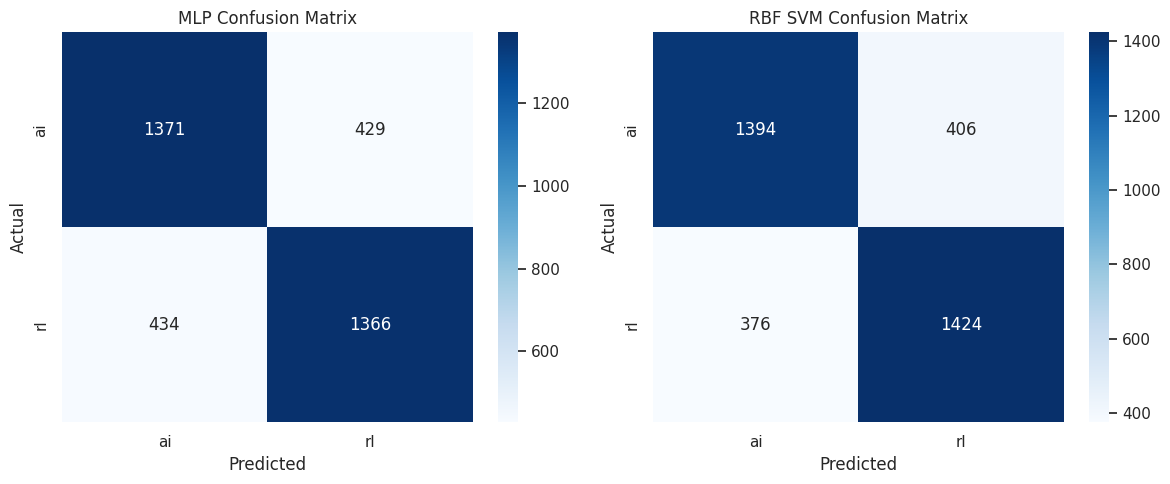


MLP Confusion Matrix (normalized):
            Predicted: ai  Predicted: rl
Actual: ai         0.7617         0.2383
Actual: rl         0.2411         0.7589

RBF SVM Confusion Matrix (normalized):
            Predicted: ai  Predicted: rl
Actual: ai         0.7744         0.2256
Actual: rl         0.2089         0.7911


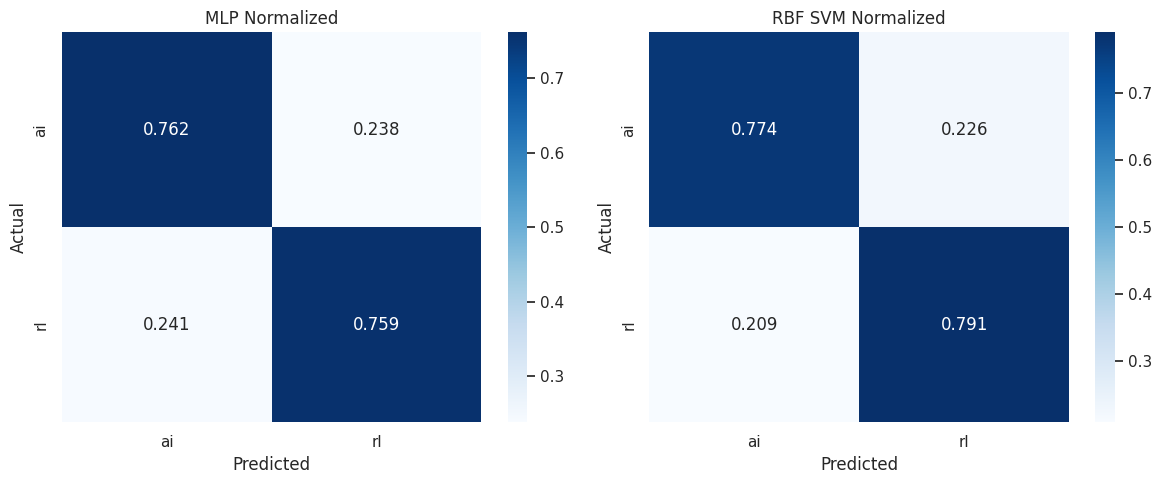

In [19]:
# ============================================================
# Cell 6: Generate and Display Confusion Matrices (Side-by-Side)
# ============================================================

# ------------------------------------------------------------
# Compute confusion matrices
# ------------------------------------------------------------
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=CLASS_LABELS)
cm_rbf = confusion_matrix(y_test, y_pred_rbf, labels=CLASS_LABELS)

print("Confusion matrices computed successfully.\n")

# ------------------------------------------------------------
# Display raw confusion matrices (tables)
# ------------------------------------------------------------
cm_mlp_df = pd.DataFrame(
    cm_mlp,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

cm_rbf_df = pd.DataFrame(
    cm_rbf,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

print("MLP Confusion Matrix (counts):")
print(cm_mlp_df)

print("\nRBF SVM Confusion Matrix (counts):")
print(cm_rbf_df)

# ------------------------------------------------------------
# Plot side-by-side confusion matrices (counts)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=axes[0]
)
axes[0].set_title("MLP Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_rbf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=axes[1]
)
axes[1].set_title("RBF SVM Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Compute normalized confusion matrices (row-wise)
# ------------------------------------------------------------
cm_mlp_normalized = cm_mlp.astype(float) / cm_mlp.sum(axis=1, keepdims=True)
cm_rbf_normalized = cm_rbf.astype(float) / cm_rbf.sum(axis=1, keepdims=True)

cm_mlp_norm_df = pd.DataFrame(
    cm_mlp_normalized,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

cm_rbf_norm_df = pd.DataFrame(
    cm_rbf_normalized,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

print("\nMLP Confusion Matrix (normalized):")
print(cm_mlp_norm_df.round(4))

print("\nRBF SVM Confusion Matrix (normalized):")
print(cm_rbf_norm_df.round(4))

# ------------------------------------------------------------
# Plot side-by-side normalized confusion matrices
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_mlp_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=axes[0]
)
axes[0].set_title("MLP Normalized")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_rbf_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=axes[1]
)
axes[1].set_title("RBF SVM Normalized")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()



ROC curves computed successfully.
Number of MLP ROC points: 1158
Number of RBF SVM ROC points: 1064


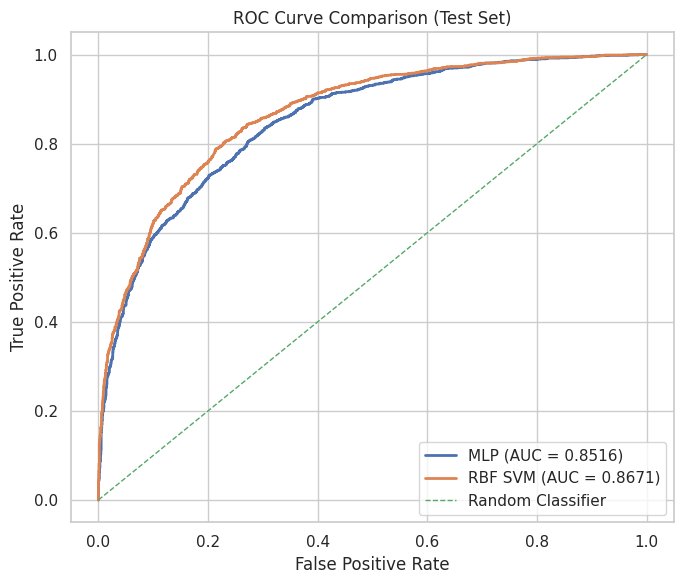


First 10 ROC points (MLP):
   threshold       fpr       tpr
0        inf  0.000000  0.000000
1   0.999999  0.000000  0.000556
2   0.998144  0.000000  0.041667
3   0.998136  0.000556  0.041667
4   0.998100  0.000556  0.043333
5   0.998068  0.001111  0.043333
6   0.997605  0.001111  0.048889
7   0.997601  0.001667  0.048889
8   0.996743  0.001667  0.063889
9   0.996728  0.002222  0.063889

First 10 ROC points (RBF SVM):
   threshold       fpr       tpr
0        inf  0.000000  0.000000
1   0.997857  0.000000  0.000556
2   0.983319  0.000000  0.041111
3   0.983056  0.000556  0.041111
4   0.975783  0.000556  0.063889
5   0.975729  0.001111  0.063889
6   0.970844  0.001111  0.081667
7   0.970808  0.001667  0.081667
8   0.954719  0.001667  0.128889
9   0.954594  0.002222  0.128889


In [20]:
# ============================================================
# Cell 7: Generate and Display ROC Curves
# ============================================================

# ------------------------------------------------------------
# Compute ROC curves
# ------------------------------------------------------------
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test_binary, y_score_mlp)
fpr_rbf, tpr_rbf, thresholds_rbf = roc_curve(y_test_binary, y_score_rbf)

print("ROC curves computed successfully.")
print(f"Number of MLP ROC points: {len(fpr_mlp)}")
print(f"Number of RBF SVM ROC points: {len(fpr_rbf)}")

# ------------------------------------------------------------
# Plot ROC curves (comparison)
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_mlp,
    tpr_mlp,
    linewidth=2,
    label=f"MLP (AUC = {roc_auc_mlp:.4f})"
)

plt.plot(
    fpr_rbf,
    tpr_rbf,
    linewidth=2,
    label=f"RBF SVM (AUC = {roc_auc_rbf:.4f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Test Set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Preview first few ROC points
# ------------------------------------------------------------
roc_preview_mlp = pd.DataFrame({
    "threshold": thresholds_mlp[:10],
    "fpr": fpr_mlp[:10],
    "tpr": tpr_mlp[:10]
})

roc_preview_rbf = pd.DataFrame({
    "threshold": thresholds_rbf[:10],
    "fpr": fpr_rbf[:10],
    "tpr": tpr_rbf[:10]
})

print("\nFirst 10 ROC points (MLP):")
print(roc_preview_mlp.round(6))

print("\nFirst 10 ROC points (RBF SVM):")
print(roc_preview_rbf.round(6))



In [21]:
# ============================================================
# Cell 8: Summarize Final Test Results in Tabular Form
# ============================================================

# ------------------------------------------------------------
# Create final results summary table
# ------------------------------------------------------------
df_final_results = pd.DataFrame([
    {
        "model": "MLP",
        "model_file": "model_mlp.pkl",
        "accuracy": accuracy_mlp,
        "precision": precision_mlp,
        "recall": recall_mlp,
        "f1_score": f1_mlp,
        "roc_auc": roc_auc_mlp
    },
    {
        "model": "RBF SVM",
        "model_file": "model_rbf_svm.pkl",
        "accuracy": accuracy_rbf,
        "precision": precision_rbf,
        "recall": recall_rbf,
        "f1_score": f1_rbf,
        "roc_auc": roc_auc_rbf
    }
])

# ------------------------------------------------------------
# Sort by ROC-AUC
# ------------------------------------------------------------
df_final_results = df_final_results.sort_values(
    by="roc_auc",
    ascending=False
).reset_index(drop=True)

print("Final test-results summary table:\n")
print(df_final_results.round(4))

# ------------------------------------------------------------
# Create report-friendly transposed summary
# ------------------------------------------------------------
df_final_results_transposed = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "MLP": [
        accuracy_mlp,
        precision_mlp,
        recall_mlp,
        f1_mlp,
        roc_auc_mlp
    ],
    "RBF SVM": [
        accuracy_rbf,
        precision_rbf,
        recall_rbf,
        f1_rbf,
        roc_auc_rbf
    ]
})

print("\nTransposed metric summary:\n")
print(df_final_results_transposed.round(4))

# ------------------------------------------------------------
# Optional: display trained model configurations
# ------------------------------------------------------------
print("\nTrained model configurations used for evaluation:\n")

for config in trained_model_configs:
    print(f"Model: {config['classifier']}")
    print(f"  ROC-AUC (CV): {config['roc_auc_mean']:.4f}")
    print(f"  Hyperparameters:")
    for k, v in config["hyperparameters"].items():
        print(f"    {k}: {v}")
    print()



Final test-results summary table:

     model         model_file  accuracy  precision  recall  f1_score  roc_auc
0  RBF SVM  model_rbf_svm.pkl    0.7828     0.7876  0.7744    0.7810   0.8671
1      MLP      model_mlp.pkl    0.7603     0.7596  0.7617    0.7606   0.8516

Transposed metric summary:

      metric     MLP  RBF SVM
0   Accuracy  0.7603   0.7828
1  Precision  0.7596   0.7876
2     Recall  0.7617   0.7744
3   F1-score  0.7606   0.7810
4    ROC-AUC  0.8516   0.8671

Trained model configurations used for evaluation:

Model: RBF SVM
  ROC-AUC (CV): 0.8790
  Hyperparameters:
    C: 10
    gamma: scale

Model: MLP
  ROC-AUC (CV): 0.8669
  Hyperparameters:
    alpha: 0.001
    hidden_layer_sizes: [64, 32]
    learning_rate_init: 0.0005



In [22]:
# ============================================================
# Cell 9: Save Final Evaluation Outputs
# ============================================================

print("Saving final evaluation outputs...\n")

# ------------------------------------------------------------
# Define output file paths
# ------------------------------------------------------------
FINAL_RESULTS_CSV_PATH = MODELS_DIR / "final_test_results.csv"
FINAL_RESULTS_JSON_PATH = MODELS_DIR / "final_test_results.json"

CONFUSION_MATRIX_MLP_CSV_PATH = MODELS_DIR / "confusion_matrix_mlp.csv"
CONFUSION_MATRIX_RBF_CSV_PATH = MODELS_DIR / "confusion_matrix_rbf_svm.csv"

ROC_POINTS_MLP_CSV_PATH = MODELS_DIR / "roc_points_mlp.csv"
ROC_POINTS_RBF_CSV_PATH = MODELS_DIR / "roc_points_rbf_svm.csv"

# ------------------------------------------------------------
# Save final metric summary table
# ------------------------------------------------------------
df_final_results.to_csv(FINAL_RESULTS_CSV_PATH, index=False)
print(f"Saved final results CSV: {FINAL_RESULTS_CSV_PATH}")

# ------------------------------------------------------------
# Save final metrics dictionary as JSON
# ------------------------------------------------------------
final_metrics = {
    "MLP": final_metrics_mlp,
    "RBF_SVM": final_metrics_rbf
}

with open(FINAL_RESULTS_JSON_PATH, "w") as f:
    json.dump(final_metrics, f, indent=4)

print(f"Saved final results JSON: {FINAL_RESULTS_JSON_PATH}")

# ------------------------------------------------------------
# Save confusion matrices
# ------------------------------------------------------------
cm_mlp_df.to_csv(CONFUSION_MATRIX_MLP_CSV_PATH)
print(f"Saved MLP confusion matrix CSV: {CONFUSION_MATRIX_MLP_CSV_PATH}")

cm_rbf_df.to_csv(CONFUSION_MATRIX_RBF_CSV_PATH)
print(f"Saved RBF SVM confusion matrix CSV: {CONFUSION_MATRIX_RBF_CSV_PATH}")

# ------------------------------------------------------------
# Save ROC curve points
# ------------------------------------------------------------
df_roc_mlp = pd.DataFrame({
    "threshold": thresholds_mlp,
    "fpr": fpr_mlp,
    "tpr": tpr_mlp
})

df_roc_rbf = pd.DataFrame({
    "threshold": thresholds_rbf,
    "fpr": fpr_rbf,
    "tpr": tpr_rbf
})

df_roc_mlp.to_csv(ROC_POINTS_MLP_CSV_PATH, index=False)
print(f"Saved MLP ROC curve points CSV: {ROC_POINTS_MLP_CSV_PATH}")

df_roc_rbf.to_csv(ROC_POINTS_RBF_CSV_PATH, index=False)
print(f"Saved RBF SVM ROC curve points CSV: {ROC_POINTS_RBF_CSV_PATH}")

print("\nAll final evaluation outputs saved successfully.")



Saving final evaluation outputs...

Saved final results CSV: /content/dip-ai-image-detection/metadata/models/final_test_results.csv
Saved final results JSON: /content/dip-ai-image-detection/metadata/models/final_test_results.json
Saved MLP confusion matrix CSV: /content/dip-ai-image-detection/metadata/models/confusion_matrix_mlp.csv
Saved RBF SVM confusion matrix CSV: /content/dip-ai-image-detection/metadata/models/confusion_matrix_rbf_svm.csv
Saved MLP ROC curve points CSV: /content/dip-ai-image-detection/metadata/models/roc_points_mlp.csv
Saved RBF SVM ROC curve points CSV: /content/dip-ai-image-detection/metadata/models/roc_points_rbf_svm.csv

All final evaluation outputs saved successfully.
